In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

from utils import preprocessing_remove_lines, preprocessing_split_by_characters, show_img

from tqdm import tqdm

In [2]:
def read_dir_images(dir_path):
    all_imgs = []
    for (root,dirs,files) in os.walk(dir_path,topdown=True):
        for file in tqdm(files, desc=f"Loading '{dir_path}' images"):
            if not file.endswith('.png'): # Remove non png
                continue
            if file.split("-")[1].split(".png")[0] != "0": # Remove bad datas
                continue
            
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)
            all_imgs.append((file.split("-")[0], preprocessing_remove_lines(img)))
    return all_imgs

In [3]:
imgs = read_dir_images('clean_train_data')
print("total imgs", len(imgs))

Loading 'clean_train_data' images: 100%|██████████████████████████████████████████| 8001/8001 [00:08<00:00, 939.47it/s]

total imgs 7812


In [4]:
imgs_after_splits = []
wrong_captchas = ""
wrong_preprocess_count = 0
for (label, img) in tqdm(imgs):
    true_char_count = len(label)
    sep_type, char_imgs = preprocessing_split_by_characters(img)
    # Insert "_" between every characters
    new_label = "_".join(list(label))
    if len(char_imgs) != true_char_count:
        wrong_preprocess_count += 1
        # Show the img
        # show_img(img, title=label)
        # show_imgs(char_imgs)
        # input(f"Label: {label} - {char_count}/{true_char_count}, new label:")
        wrong_captchas += label + "\n"
    imgs_after_splits.append((new_label, char_imgs))
print(wrong_preprocess_count, "wrong preprocess count")
print(wrong_captchas)

100%|██████████████████████████████████████████████████████████████████████████████| 7812/7812 [05:34<00:00, 23.35it/s]

370 wrong preprocess count
010ud
0axhfa
0d0vp1
0duo1r
0dw9b7hd
0fn5eioh
0h7htrjq
0hox6
0ihk7bk
0pbri
0xnsjn
115cip
1b30y
1jgt
1u5b3hlt
1vbc15z
1w572r
1wmebgw
1y2lk
20tzku6e
25927mqe
26x1pa
2at5l1k9
2cg2og8e
2f48g
2fgthyo9
2hr9d9
2kiz79h
2nsg1gl
2ogcaj
2xdkqt
32u4n
3otukim
3pp1pc
3qi9bll
3yfc6jy
422g0b
43u1voui
45p9d
480c
4ih1w4
4jjv
4n8j076k
4roslcx
4vatp9k7
4wtr
503s2qx
59nl1yr5
5fk4me
5ie69wtf
5ifb3
5n95t
5ycx
5yiwz
63xvslow
66ee9e6x
67zs
6c4p6qhc
6cso3
6igl
6ioem8o
6ocl0d1
6qaiv
6soqfbku
6toeeyqt
6xl3aw
6zdkq7o
74njaeh
74r1c319
765iii9
76sp8v
76wc
7dqtxy
7ev3f8kb
7fnlfb4t
7fptq5ti
7genwgh
7heenhd
7o68a
7qr4opg
7rl3w0
7s0txxh
7twrv
7wblk87v
80a79g
88iaqi
8l3lyuq8
8nitobic
8nogbc
8o8379d
8shgmq
8u2yxjmu
96gvsow
99mqhb
9abwl0a
9bqm45xe
9e3j1oj
9e83qa
9i3vx
9ppub
9xgdgd5
9z1i35l
a1pmqmw
a5tch15i
a70ond9c
ai0wt
al7qec9
amslm023
aqdlgv9
auijw0
b0mpqzx
b76ojrh
b8ceaq6
bev3
bhcdr2wh
bi1a
bvrejwz
bzs716r
c3sco
c4tcia
cc8y
cccjvgm
cchiy0a
ckp24c3b
clc5lmda
cnsb
crcqbkqh
cuc3nw
cwa10k7
cx2ysb


In [5]:
# import cv2
# from sklearn.cluster import DBSCAN

# def segment_by_color(
#     img: np.ndarray, 
#     hue_tolerance: int = 5,  # <-- Tuned parameter
#     min_pixel_area: int = 31,  # <-- Tuned parameter
#     db_min_samples: int = 27   # <-- Tuned parameter
# ) -> tuple[int, list[np.ndarray]]:
#     """
#     Segments a CAPTCHA image using color clustering:
#     - Uses a VERTICAL kernel (3,5) to connect 'i' dots/stems
#       without merging horizontally-adjacent chars (like '7bm').
    
#     Args:
#         img: The input RGB image (as a NumPy array).
#         hue_tolerance: The max distance (eps) between hues for one cluster.
#         min_pixel_area: Min pixels for a *final spatial component*.
#         db_min_samples: Min pixels to form a *color cluster*.
    
#     Returns:
#         A tuple of (character_count, list_of_character_images).
#     """
    
#     # 1. Convert to HSV color space
#     hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
#     # 2. Create a mask to filter out ONLY the white background
#     s_channel = hsv[:, :, 1]
#     v_channel = hsv[:, :, 2]
    
#     s_thresh = 5   # Max saturation to be "pure white"
#     v_thresh = 250 # Min value to be "pure white"
    
#     bg_mask = cv2.bitwise_and(
#         cv2.compare(s_channel, s_thresh, cv2.CMP_LT), # S < s_thresh
#         cv2.compare(v_channel, v_thresh, cv2.CMP_GT)  # V > v_thresh
#     )
    
#     fg_mask = cv2.bitwise_not(bg_mask)
    
#     # 3. Get all foreground (colored) pixel hues
#     y_coords, x_coords = np.where(fg_mask > 0)
#     if len(y_coords) < min_pixel_area: 
#         return 0, []
    
#     print(hsv[y_coords, x_coords, 0].shape)
#     hues = hsv[y_coords, x_coords, 0].reshape(-1, 1)
#     print(hues.shape)
#     plt.scatter(hues)
#     plt.show()
#     # 4. Cluster the HUE values
#     db = DBSCAN(eps=hue_tolerance, min_samples=db_min_samples).fit(hues)
#     labels = db.labels_
    
#     unique_labels = set(labels)
#     char_images = []
#     char_bboxes = []
    
#     # 5. Create an image for each color cluster (character)
#     for label in unique_labels:
#         if label == -1: # Skip noise
#             continue
        
#         cluster_mask = np.zeros(img.shape[:2], dtype="uint8")
        
#         cluster_indices = np.where(labels == label)[0]
#         cluster_y = y_coords[cluster_indices]
#         cluster_x = x_coords[cluster_indices]
        
#         cluster_mask[cluster_y, cluster_x] = 255
        
#         # 6. Clean up the mask (connect nearby parts of the same color)
        
#         # A (3,5) kernel is 3px wide and 5px tall.
#         # It's more aggressive at closing VERTICAL gaps (like 'i')
#         # than horizontal gaps (like '7bm').
#         kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 5)) 
#         closed_mask = cv2.morphologyEx(cluster_mask, cv2.MORPH_CLOSE, kernel, iterations=1)
        
#         # 7. Find ALL characters from the color cluster mask
#         num_components, comp_labels, stats, _ = \
#             cv2.connectedComponentsWithStats(closed_mask, 8, cv2.CV_32S)
        
#         if num_components <= 1: # Only background
#             continue

#         # Loop through all found components (skip 0, the background)
#         for i in range(1, num_components):
            
#             # 8. Filter small components by area
#             area = stats[i, cv2.CC_STAT_AREA]
#             if area < min_pixel_area:
#                 continue
                
#             # 9. Extract this component as a character
#             final_mask = (comp_labels == i)
            
#             y_pix, x_pix = np.where(final_mask)
#             if len(x_pix) == 0:
#                 continue
            
#             x_min = x_pix.min()
            
#             char_img = np.full_like(img, 255, dtype=np.uint8)
#             char_img[final_mask] = img[final_mask]
            
#             char_images.append(char_img)
#             char_bboxes.append(x_min)
            
#     # 10. Sort characters left-to-right
#     if char_bboxes:
#         sorted_indices = np.argsort(char_bboxes)
#         char_images = [char_images[i] for i in sorted_indices]
    
    
#     return len(char_images), char_images

In [6]:
import cv2
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
def am_power(a):
    dim1 = a.shape
    
    if len(dim1)==2:
        sz = dim1[0] * dim1[1] 
    elif len(dim1)==3:
        sz = dim1[0] * dim1[1] * dim1[2]        
    pa = np.sum( a ** 2.0) / sz    
    
    return pa
def preprocessing_split_by_characters(img: np.ndarray) -> tuple[int, list[np.ndarray]]:
    grey = np.mean(img, axis=2)
    grey_no_white = np.where(grey == 255, 0, 1)
    if am_power(grey_no_white) < 0.02:
        return 0, split_by_column(img)[1]
    else:
        return 1, segment_by_color(img)[1]

def split_by_column(img: np.ndarray) -> tuple[int, list[np.ndarray]]:
    grey_scale = img.mean(axis=2)
    grey_scale = cv2.GaussianBlur(grey_scale, (5,5), 0)
    
    col_values = np.where(grey_scale == 255, 0, 1)
    col_values = np.sum(col_values, axis=0)
    
    find_left = True
    unique_cols_range = []
    left = 0
    for i in range(len(col_values) - 1):
        if find_left and col_values[i] == 0 and col_values[i + 1] > 0:
            left = i
            find_left = False
        elif not find_left and col_values[i] > 0 and col_values[i + 1] == 0:
            right = i + 1
            unique_cols_range.append((left, right))
            find_left = True
    
    char_images = []
    for r in unique_cols_range:
        char_img = np.ones_like(img) * 255
        char_img[:, r[0]:r[1], :] = img[:, r[0]:r[1], :]
        char_images.append(char_img)

    return len(char_images), char_images
def segment_by_color(
    img: np.ndarray, 
    eps: float = 0.5,           # DBSCAN neighborhood radius (tuned)
    min_pixel_area: int = 31,   # Minimum pixel count per final blob
    db_min_samples: int = 27,   # Minimum pixels to form a cluster
    spatial_weight: float = 0.1  # Controls importance of x,y distance
) -> tuple[int, list[np.ndarray]]:
    """
    Segments a CAPTCHA image using spatial + color (hue) clustering.

    - Converts image to HSV and filters out white background.
    - Maps hue to (cos, sin) to handle circular hue wraparound.
    - Clusters in 4D space: (x, y, cos(hue), sin(hue)) using DBSCAN.
    - Merges small gaps vertically to connect 'i' stems/dots.
    
    Args:
        img: Input RGB (or BGR) image as NumPy array.
        eps: DBSCAN neighborhood size (after scaling).
        min_pixel_area: Minimum size for a valid character blob.
        db_min_samples: Minimum samples for DBSCAN cluster.
        spatial_weight: Relative importance of spatial vs color distance.
    
    Returns:
        (character_count, list_of_character_images)
    """
    # --- 1. Convert to HSV ---
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s_channel = hsv[:, :, 1]
    v_channel = hsv[:, :, 2]

    # --- 2. Filter out white background ---
    s_thresh = 5
    v_thresh = 250
    bg_mask = cv2.bitwise_and(
        cv2.compare(s_channel, s_thresh, cv2.CMP_LT),
        cv2.compare(v_channel, v_thresh, cv2.CMP_GT)
    )
    fg_mask = cv2.bitwise_not(bg_mask)

    y_coords, x_coords = np.where(fg_mask > 0)
    if len(y_coords) < min_pixel_area:
        return 0, []

    # --- 3. Get hue values and map to circular coords ---
    hues = hsv[y_coords, x_coords, 0].astype(np.float32) / 180.0  # normalize hue to [0,1]
    hue_x = np.cos(2 * np.pi * hues)
    hue_y = np.sin(2 * np.pi * hues)

    # --- 4. Combine features: spatial + color ---
    features = np.column_stack([
        y_coords, 
        x_coords,
        hue_x,
        hue_y
    ])

    # --- 5. Normalize features (to make x,y comparable to hue) ---
    features_scaled = StandardScaler().fit_transform(features)
    features_scaled[:, :2] *= spatial_weight  # re-apply spatial weight after scaling

    # --- 6. DBSCAN clustering ---
    db = DBSCAN(eps=eps, min_samples=db_min_samples).fit(features_scaled)
    labels = db.labels_
    unique_labels = set(labels)

    char_images = []
    char_bboxes = [[],[]]

    # --- 7. Build masks for each cluster ---
    for label in unique_labels:
        if label == -1:
            continue  # skip noise

        cluster_mask = np.zeros(img.shape[:2], dtype="uint8")
        cluster_idx = np.where(labels == label)[0]
        cluster_y = y_coords[cluster_idx]
        cluster_x = x_coords[cluster_idx]
        cluster_mask[cluster_y, cluster_x] = 255

        # --- 8. Morphological close (vertical kernel) ---
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 5))
        closed_mask = cv2.morphologyEx(cluster_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

        # --- 9. Find connected components (characters) ---
        num_comp, comp_labels, stats, _ = cv2.connectedComponentsWithStats(closed_mask, 8, cv2.CV_32S)
        if num_comp <= 1:
            continue

        for i in range(1, num_comp):
            area = stats[i, cv2.CC_STAT_AREA]
            if area < min_pixel_area:
                continue

            final_mask = (comp_labels == i)
            y_pix, x_pix = np.where(final_mask)
            if len(x_pix) == 0:
                continue

            x_min = x_pix.min()
            x_max = x_pix.max()

            # Create character image
            char_img = np.full_like(img, 255, dtype=np.uint8)
            char_img[final_mask] = img[final_mask]

            char_images.append(char_img)
            char_bboxes[0].append(x_min)
            char_bboxes[1].append(x_max)
        

    # --- 10. Sort characters left-to-right ---
    if char_bboxes:
        sorted_idx = np.argsort(char_bboxes[0])
        char_images = [char_images[i] for i in sorted_idx]

    # --- 11. Merge similar hue value and neighbour imgs
    hue_diff_thres = 0.1
    fin_images = []
    i = 0
    while( i < len(char_images)):
        if i == len(char_images) - 1:
            fin_images.append(char_images[i])
            break
        min_i, max_i = char_bboxes[0][i], char_bboxes[1][i]
        min_j, max_j = char_bboxes[0][i + 1], char_bboxes[1][i + 1]
        mean_i = (min_i + max_i) / 2
        mean_j = (min_j + max_j) / 2
        is_contain = (min_i < mean_j and max_i > mean_j) or (min_j < mean_i and max_j > mean_i)
        print(mean_hue(char_images[i])- mean_hue(char_images[i+1]))
        if is_contain and abs(mean_hue(char_images[i])- mean_hue(char_images[i+1])) < hue_diff_thres:
            fin_images.append(char_images[i] + char_images[i+1])
            i += 2
        else:
            fin_images.append(char_images[i])
            i += 1

    return len(fin_images), fin_images

In [7]:
def mean_hue(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    grey = np.mean(img,axis=2)
    return np.sum(np.where(grey!=255, hsv[:,:,0],0)) / np.sum(np.where(grey!=255, 1,0))

-69.35099387636082
124.16141332823247
-0.32798573975044576
-50.51549199863806
76.85084398712941


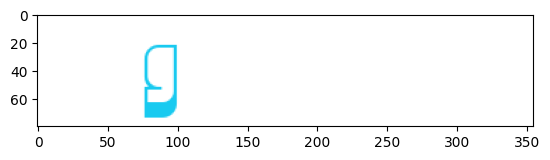

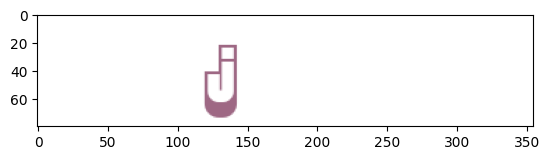

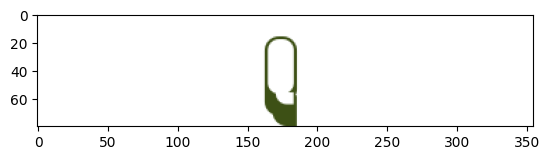

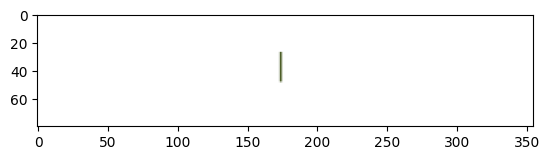

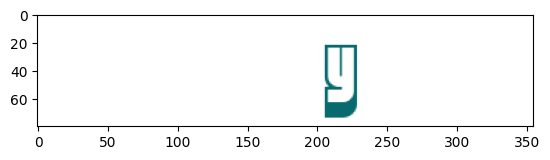

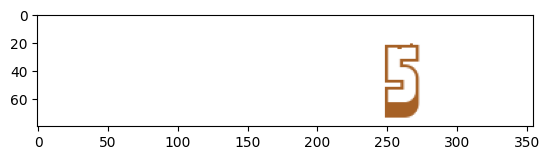

In [8]:
def find_label(label):
    for l, img in imgs:
        if label == l:
            return img
img = find_label("gjqy5")
_, i = preprocessing_split_by_characters(img)
for img in i:
    show_img(img)

In [10]:
import string
print(list(string.ascii_lowercase))

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
